In [1]:
# Loading Basic Libraries 
import os
import gc   # No Version
from pathlib import Path

import random
import six
import sys
import warnings

import dataclasses
from dataclasses import dataclass, field
from typing import Dict, Any, Tuple, Union, List, Optional, Mapping
from tqdm import tqdm
from tqdm.notebook import tqdm

import yaml
import pickle

In [2]:
# Loading Data Processing Libraries 
import numpy as np
import pandas as pd

from logging import getLogger

In [3]:
# Loading Visualization Libraries 
from IPython.core.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as ptc
import seaborn as sns

from plotly import tools, subplots
import plotly.offline as py

import plotly.graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
import plotly.io as pio

C:\Users\hp\AppData\Local\Temp\ipykernel_10564\4233372780.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [4]:
# Loading Statistics Libraries 
import scipy as sp
# Loading Models Libraries 
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import torch
import torch.nn.functional as F
from torch import nn
from torch.nn import Linear
from torch import nn, optim
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import Dataset

In [1]:
import tensorflow as tf  
import os  
import random  

def load_limited_images_from_folder(folder, limit):  
    images, labels = [], []  
    all_filenames = [f for f in os.listdir(folder) if f.endswith('.png')]  
    
    # Randomly select 'limit' images  
    selected_filenames = random.sample(all_filenames, min(limit, len(all_filenames)))  
    
    for filename in selected_filenames:  
        img_path = os.path.join(folder, filename)  
        img = tf.keras.preprocessing.image.load_img(img_path)  
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]  
        images.append(img_array)  
        labels.append(filename)  # Use the filename or parse it for labels  
    
    return tf.convert_to_tensor(images), labels  

# Define constants   
limit_train = 3000  
limit_test = 500   

# Load training and testing datasets with a limit  
train_images, train_labels = load_limited_images_from_folder('D:/vinbigdata_dataset/train', limit_train)  
test_images, test_labels = load_limited_images_from_folder('D:/vinbigdata_dataset/test', limit_test)  

# Check the shape of the loaded images  
print(train_images.shape) 

: 

In [ ]:
# import tensorflow as tf  
# import os  

# def load_images_from_folder(folder):  
#     images, labels = [], []  
#     all_filenames = [f for f in os.listdir(folder) if f.endswith('.png')]  
    
#     for filename in all_filenames:  
#         img_path = os.path.join(folder, filename)  
#         img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))  # Resize to a uniform size
#         img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]  
#         images.append(img_array)  
#         labels.append(filename)  # Use filename or parse it for labels  
    
#     return tf.convert_to_tensor(images), labels  

# # Load training and testing datasets
# train_images, train_labels = load_images_from_folder('D:/vinbigdata_dataset/train')  
# test_images, test_labels = load_images_from_folder('D:/vinbigdata_dataset/test')  

# # Check the shape of the loaded images  
# print(train_images.shape)
# print(test_images.shape)


In [8]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np

# Define constants
IMG_SIZE = 224  # Resize images to a uniform size
NUM_CLASSES = 15  # Includes "No finding"
BATCH_SIZE = 32

# Define function to preprocess a single image
def preprocess_image(image_path):
    image = tf.keras.preprocessing.image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    image = tf.keras.preprocessing.image.img_to_array(image) / 255.0  # Normalize to [0, 1]
    return image

# Function to load data
def load_dataset(folder, csv_path):
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Add full file paths to the dataframe
    df['file_path'] = df['image_id'].apply(lambda x: os.path.join(folder, f"{x}.png"))
    
    # Preprocess images
    images = np.array([preprocess_image(path) for path in df['file_path']])
    
    # One-hot encode labels
    labels = tf.keras.utils.to_categorical(df['class_id'], num_classes=NUM_CLASSES)
    
    return images, labels

# Paths to dataset folders and CSV
train_folder = "D:/vinbigdata_dataset/train"
test_folder = "D:/vinbigdata_dataset/test"
train_csv = "D:/vinbigdata_dataset/train.csv"
test_csv = "D:/vinbigdata_dataset/test.csv"

# Load datasets
train_images, train_labels = load_dataset(train_folder, train_csv)
test_images, test_labels = load_dataset(test_folder, test_csv)

# Print dataset shapes
print(f"Train Images Shape: {train_images.shape}, Train Labels Shape: {train_labels.shape}")
print(f"Test Images Shape: {test_images.shape}, Test Labels Shape: {test_labels.shape}")


MemoryError: Unable to allocate 588. KiB for an array with shape (224, 224, 3) and data type float32

In [7]:
print(test_images.shape)

(500, 512, 512, 3)


In [8]:
train_df = pd.read_csv("D:/vinbigdata_dataset/train.csv")


In [9]:
train_df

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max,width,height
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN,2332,2580
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN,2954,3159
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0,2080,2336
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0,2304,2880
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN,2540,3072
...,...,...,...,...,...,...,...,...,...,...
67909,936fd5cff1c058d39817a08f58b72cae,No finding,14,R1,NaN,NaN,NaN,NaN,2444,3200
67910,ca7e72954550eeb610fe22bf0244b7fa,No finding,14,R1,NaN,NaN,NaN,NaN,1994,2430
67911,aa17d5312a0fb4a2939436abca7f9579,No finding,14,R8,NaN,NaN,NaN,NaN,2048,2500
67912,4b56bc6d22b192f075f13231419dfcc8,Cardiomegaly,3,R8,771.0,979.0,1680.0,1311.0,1968,2040


Preprocessing Labels

In [30]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer


# Extract labels (class_id) for selected filenames
train_labels_dict = {filename.split('.')[0]: [] for filename in train_labels}
for _, row in train_df.iterrows():
    if row['image_id'] in train_labels_dict:
        train_labels_dict[row['image_id']].append(row['class_id'])


mlb = MultiLabelBinarizer()
encoded_labels = mlb.fit_transform(list(train_labels_dict.values()))

train_label_map = {filename: encoded_label for filename, encoded_label in zip(train_labels, encoded_labels)}

train_encoded_labels = tf.convert_to_tensor([train_label_map[label] for label in train_labels])


In [31]:
train_df.isna().sum().to_frame().rename(columns={0:"Nan_counts"}).style.background_gradient(cmap="cool")

,Nan_counts
image_id,0
class_name,0
class_id,0
rad_id,0
x_min,31818
y_min,31818
x_max,31818
y_max,31818
width,0
height,0


In [32]:
train_df.nunique().to_frame().rename(columns={0:"Unique Values"}).style.background_gradient(cmap="plasma")

,Unique Values
image_id,15000
class_name,15
class_id,15
rad_id,17
x_min,2521
y_min,2570
x_max,2644
y_max,2714
width,1036
height,1127


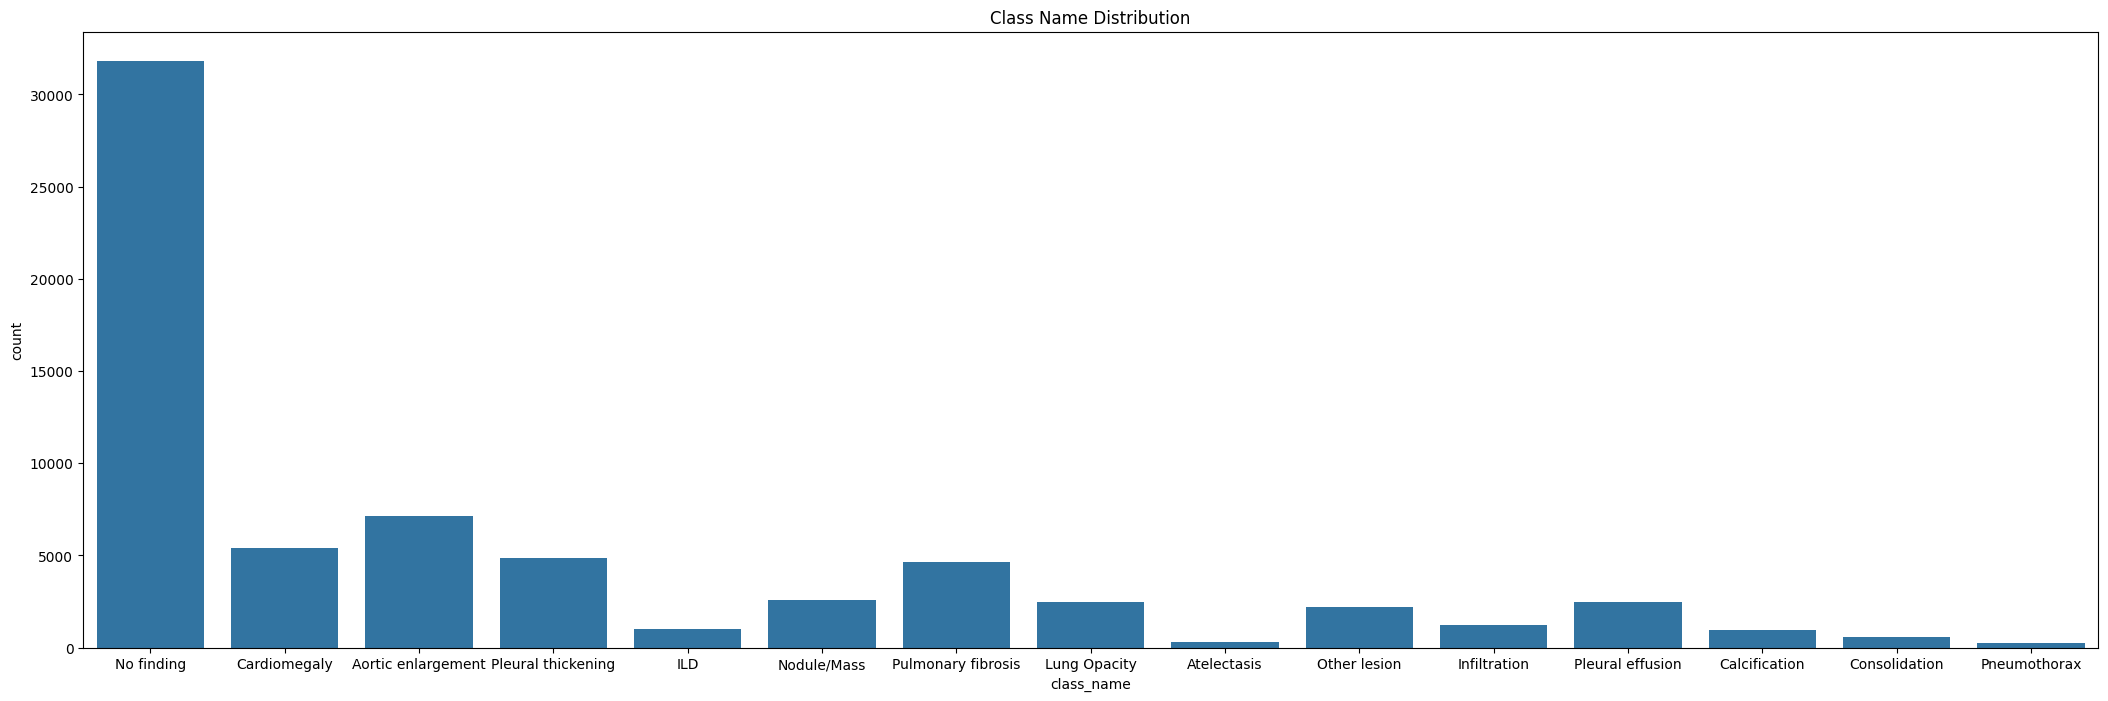

In [33]:
plt.figure(figsize=(26, 8))
sns.countplot(x="class_name", data=train_df)
plt.title("Class Name Distribution")
plt.show()

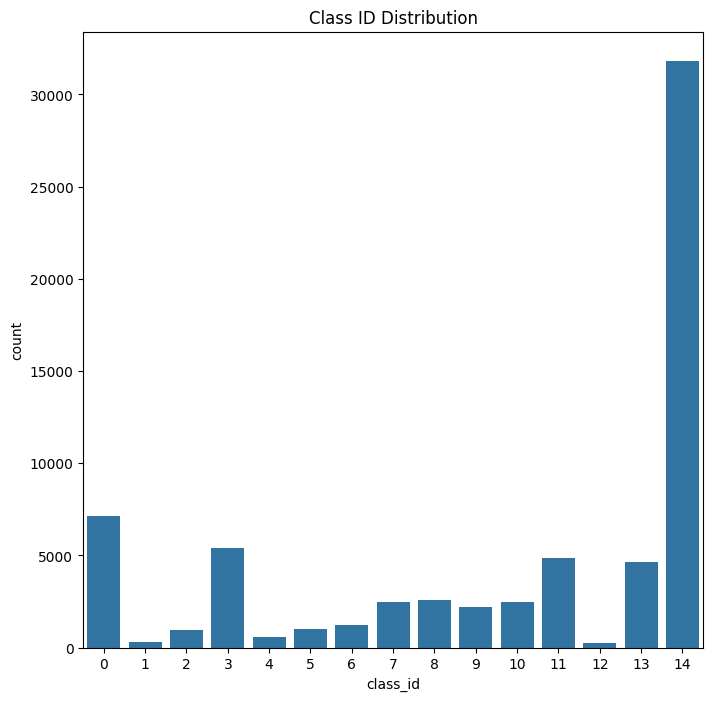

In [13]:
plt.figure(figsize=(8, 8))
sns.countplot(x="class_id", data=train_df)
plt.title("Class ID Distribution")
plt.show()

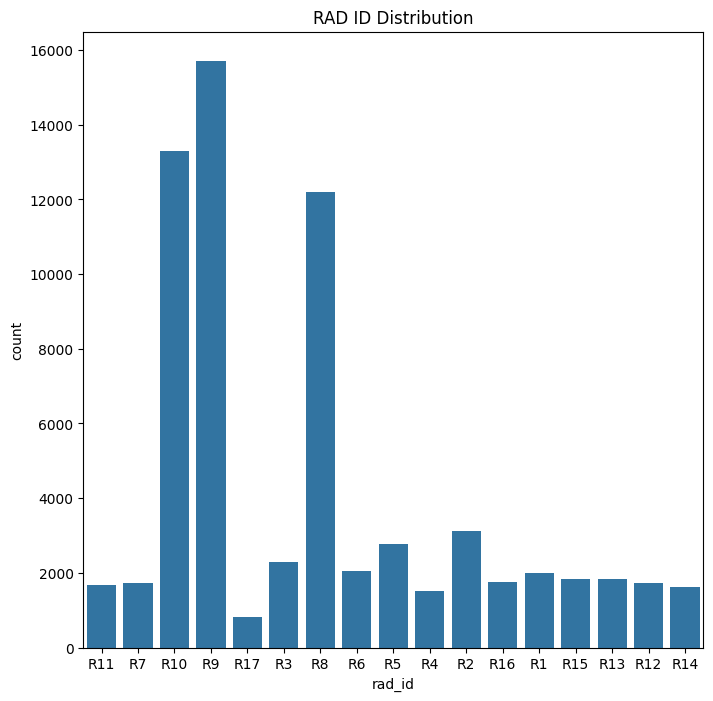

In [14]:
plt.figure(figsize=(8, 8))
sns.countplot(x="rad_id", data=train_df)
plt.title("RAD ID Distribution")
plt.show()

In [16]:
print("Number of train images: ", len(train_images))
print("Number of test images: ", len(test_images))

Number of train images:  3000
Number of test images:  500


In [17]:
print("Unique images in train_df: ", train_df.image_id.nunique())

Unique images in train_df:  15000


Images

Display sample images from training dataset  

Sample Images from Dataset:


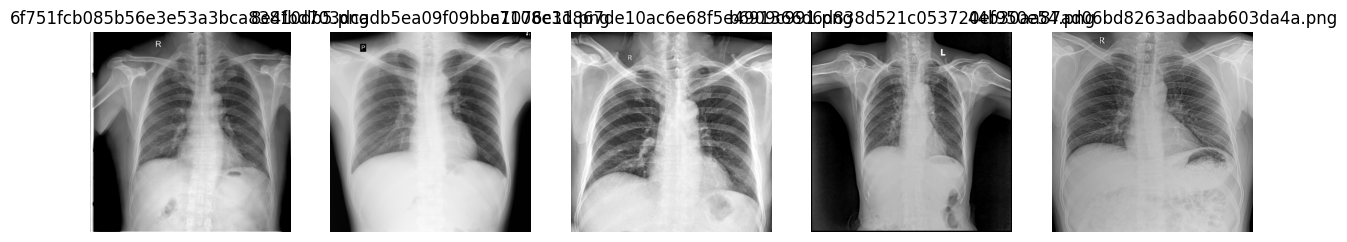

Shape of training images: (3000, 512, 512, 3)
Data type of training images: <dtype: 'float32'>


In [27]:
import matplotlib.pyplot as plt  

# Function to visualize specific sample images directly from the tensor  
def plot_images(images_tensor, labels, num_images=5):  
    plt.figure(figsize=(15, 5))  
    for i in range(num_images):  
        # Select specific image directly from the tensor without converting to a NumPy array  
        plt.subplot(1, num_images, i + 1)  
        plt.imshow(images_tensor[i])  # Display the image  
        plt.axis('off')  # Hide axis  
        plt.title(labels[i])  # Use filename as title  
    plt.show()  

# 1. Visualize Sample Images  
print("Sample Images from Dataset:")  
plot_images(train_images, train_labels, num_images=5)  # Show 5 sample images  

# 2. Check the shape and type of the loaded images  
print("Shape of training images:", train_images.shape)  
print("Data type of training images:", train_images.dtype)  

 


In [28]:
def extract_labels_from_filenames(filenames):  
    # Adjust according to your filename structure  
    return [filename.split('_')[0] for filename in filenames] 
train_class_labels = extract_labels_from_filenames(train_labels)  
class_distribution = Counter(train_class_labels) 

# Print class distribution  
print("Class distribution in training dataset:")  
for class_label, count in class_distribution.items():  
    print(f"{class_label}: {count} images")  



Class distribution in training dataset:
6f751fcb085b56e3e53a3bca83810db5.png: 1 images
8e4fbd703dcadb5ea09f09bbc7108e11.png: 1 images
a1076c3d867de10ac6e68f5e4909c991.png: 1 images
b691366d6d838d521c053720ef950e54.png: 1 images
44b30aa87ad06bd8263adbaab603da4a.png: 1 images
32c05ef69ce090ebbdaa6741c21afc01.png: 1 images
d838d59a9362d4a4b768cea5419cf190.png: 1 images
e9ff892454b40672f41ead3020a084a6.png: 1 images
afc6fb73eec576696b80c9deec2d3463.png: 1 images
0fa646e920286af9f1496ca1e7b5c8be.png: 1 images
c122603c15e999d44c2533aa4d62f203.png: 1 images
ab5a33b1a98f405f60d41b563e741164.png: 1 images
92928a912d1736877050c8c00c3dacdb.png: 1 images
bd2c160cd78820ef799b5f0e8d6a1de9.png: 1 images
f0cdee7dafbadaa45400c602b995b30f.png: 1 images
1a96431bc7903b5049ae70fc5a7d8965.png: 1 images
45a8f56d50665a20a709eacad6f3ba9a.png: 1 images
a6815b18ea16692006a4fc6c26fba868.png: 1 images
ad21e3f856bd69daf2ee8b6699bd32cf.png: 1 images
9be65912706ff1be275d796357999a33.png: 1 images
387c821b242fc27b6d86

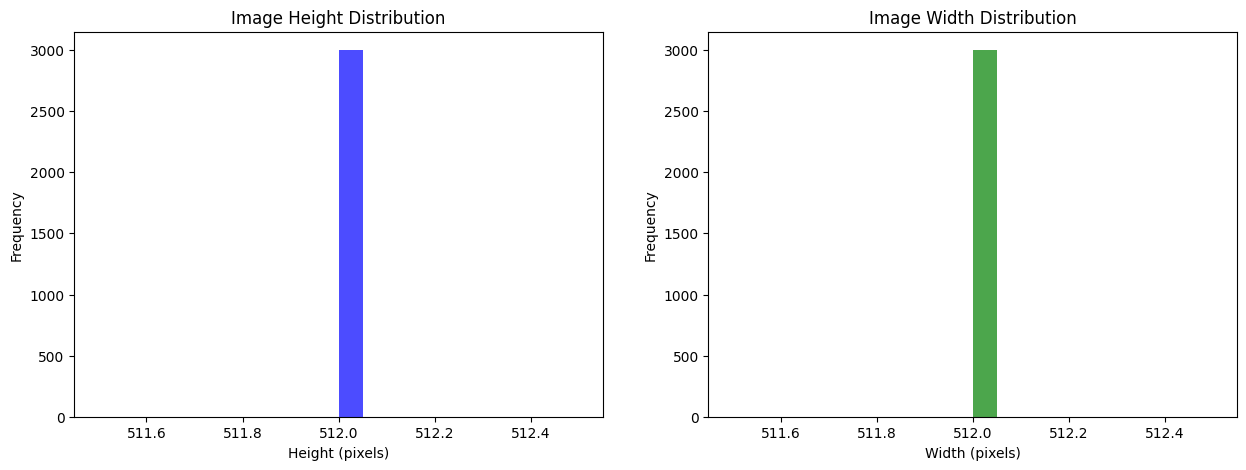

Unique image shapes in dataset: {(512, 512)}


In [29]:
# 4. Image Size Analysis  
# Use the Tensor flow tensor directly to check heights and widths  
heights = [img.shape[0] for img in train_images]  
widths = [img.shape[1] for img in train_images]  

# Plot histograms of image heights and widths  
plt.figure(figsize=(15, 5))  

plt.subplot(1, 2, 1)  
plt.hist(heights, bins=20, color='blue', alpha=0.7)  
plt.title('Image Height Distribution')  
plt.xlabel('Height (pixels)')  
plt.ylabel('Frequency')  

plt.subplot(1, 2, 2)  
plt.hist(widths, bins=20, color='green', alpha=0.7)  
plt.title('Image Width Distribution')  
plt.xlabel('Width (pixels)')  
plt.ylabel('Frequency')  

plt.show()  

# 5. Check for Unique Shapes  
unique_shapes = set((img.shape[0], img.shape[1]) for img in train_images)  
print(f"Unique image shapes in dataset: {unique_shapes}")

Dataset Splitting



In [39]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Normalize the images (already in Tensor format)
train_images_normalized = train_images / 255.0

# Generate random indices for splitting
indices = tf.range(len(train_images_normalized))
shuffled_indices = tf.random.shuffle(indices)

# Calculate the split index
split_index = int(0.8 * len(train_images_normalized))

# Perform the split directly on tensors
train_indices = shuffled_indices[:split_index]
val_indices = shuffled_indices[split_index:]

# Create train and validation splits
X_train_tensor = tf.gather(train_images_normalized, train_indices)
y_train_tensor = tf.gather(train_encoded_labels, train_indices)
X_val_tensor = tf.gather(train_images_normalized, val_indices)
y_val_tensor = tf.gather(train_encoded_labels, val_indices)

# Print shapes to confirm
print(f"Train Images Shape: {X_train_tensor.shape}")
print(f"Validation Images Shape: {X_val_tensor.shape}")
print(f"Train Labels Shape: {y_train_tensor.shape}")
print(f"Validation Labels Shape: {y_val_tensor.shape}")

# Free up memory (if needed)
gc.collect()


ResourceExhaustedError: {{function_node __wrapped__RealDiv_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[3000,512,512,3] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator cpu [Op:RealDiv] name: 